# Google OR-Tools Model
Build the mathematical model explicitly in OR-Tools, run replenishment plan and holdout performance.

In [1]:
from pathlib import Path
import json, time
import numpy as np
import pandas as pd
from IPython.display import display
PROJECT_ROOT = Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT/'data'
RESULTS_DIR = PROJECT_ROOT/'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SETTINGS = json.loads((DATA_DIR/'project_settings.json').read_text(encoding='utf-8'))
conf = json.loads((DATA_DIR/'config.json').read_text(encoding='utf-8'))
params = pd.read_csv(DATA_DIR/'sku_parameters_ASSUMED.csv').set_index('sku')
train_scenarios = pd.read_csv(DATA_DIR/'train_scenarios.csv')
SKUS = tuple(sorted(params.index.tolist()))
HORIZON = int(SETTINGS['horizon'])
SERVICE_LEVEL = float(conf['service_level'])
WAREHOUSE_CAPACITY = float(conf['warehouse_capacity'])
TIME_LIMIT_SECONDS = int(SETTINGS['time_limit_seconds'])
print('Loaded saved common inputs')

Loaded saved common inputs


In [2]:
# Build a small input dictionary
I = tuple(SKUS)
T = tuple(range(HORIZON))
S = tuple(sorted(train_scenarios['scenario'].unique()))
pairs = train_scenarios[['scenario','probability']].drop_duplicates()
assert not pairs['scenario'].duplicated().any()
prob = {str(r.scenario):float(r.probability) for r in pairs.itertuples(index=False)}
D = {(str(r.sku),int(r.week),str(r.scenario)):float(r.demand)
     for r in train_scenarios.itertuples(index=False)}
expected_keys = {(i,t,s) for i in I for t in T for s in S}
assert set(D) == expected_keys, 'Missing/duplicate SKU-week-scenario combinations.'
assert len(train_scenarios) == len(expected_keys)
assert abs(sum(prob.values()) - 1.0) < 1e-9
assert all(v >= 0 for v in D.values())
EXPECTED_DEMAND = sum(prob[s] * D[i,t,s] for i in I for t in T for s in S)
ALLOWED_EXPECTED_LOSS = (1-SERVICE_LEVEL) * EXPECTED_DEMAND
print('SKUs:',len(I),'weeks:',len(T),'scenarios:',len(S))
print('Expected units requested:', round(EXPECTED_DEMAND,2))
print('Expected lost-unit budget at 95% aggregate fill:', round(ALLOWED_EXPECTED_LOSS,2))

SKUs: 6 weeks: 6 scenarios: 16
Expected units requested: 8745.44
Expected lost-unit budget at 95% aggregate fill: 437.27


## Mathematical Formulation

Sets: $i\in\mathcal I$ SKU, $t\in\{0,\ldots,5\}$ week, $s\in\mathcal S$ demand scenario, with probability $p_s$.

**First-stage variables:** $q_{it}\in\mathbb Z_{\ge0}$ units ordered, $y_{it}\in\{0,1\}$ ordering/setup indicator. They form one fixed six-week plan shared by all scenarios.

**Scenario-dependent variables:** $I_{its}\ge0$ end-week inventory, $L_{its}\ge0$ lost units, $W_{its}\ge0$ disposed units.

**Objective:**
$$\min\ \sum_{i,t}(c_iq_{it}+f_iy_{it})+\sum_sp_s\sum_{i,t}(h_iI_{its}+b_iL_{its}+w_iW_{its}).$$

**Constraints** (all apply to *each* relevant SKU, week, scenario):

1. **Order linking:** $q_{it}\le M_i y_{it}$, and $0\le q_{it}\le M_i$.
2. **Inventory balance:** $I_{its}=I_{i,t-1,s}+q_{it}-d_{its}+L_{its}-W_{its}$; replace $I_{i,-1,s}$ with known initial inventory at $t=0$.
3. **Lost-sales bounds:** $0\le L_{its}\le d_{its}$.
4. **End-week capacity:** $\sum_i I_{its}\le C$ for each $(t,s)$.
5. **Aggregate expected fill rate:** $\sum_sp_s\sum_{i,t}L_{its}\le (1-\alpha)\sum_sp_s\sum_{i,t}d_{its}$ with $\alpha=0.95$.

# OR-Tools Implementation

In [3]:
SHOW_SOLVER_LOG = False
try:
    from ortools.linear_solver import pywraplp
    ORTOOLS_AVAILABLE = True
    print('OR-Tools/CBC interface imported.')
except (ImportError, OSError) as exc:
    ORTOOLS_AVAILABLE = False
    print('OR-Tools unavailable:',exc)
ortools_plan, ortools_stats = None, None

OR-Tools/CBC interface imported.


### STEP A: create model and first-stage variables.

In [4]:
if ORTOOLS_AVAILABLE:
    o_start = time.perf_counter()
    om = pywraplp.Solver.CreateSolver('CBC')
    if om is None:
        ORTOOLS_AVAILABLE = False
        print('CBC backend not found in your OR-Tools installation.')
    else:
        om.SetTimeLimit(int(TIME_LIMIT_SECONDS * 1000))  # OR-Tools uses milliseconds
        if SHOW_SOLVER_LOG:
            om.EnableOutput()
        oq = {(i,t):om.IntVar(0,int(params.loc[i,'max_order_per_week']), f'order[{i},{t}]')
              for i in I for t in T}
        oy = {(i,t):om.IntVar(0,1,f'order_flag[{i},{t}]') for i in I for t in T}
        print('Created OR-Tools/CBC model and first-stage variables.')

Created OR-Tools/CBC model and first-stage variables.


### STEP B: create the scenario-dependent recourse variables.

In [5]:
if ORTOOLS_AVAILABLE:
    oinv = {(i,t,s):om.NumVar(0,om.infinity(),f'inventory[{i},{t},{s}]')
            for i in I for t in T for s in S}
    olost = {(i,t,s):om.NumVar(0,D[i,t,s],f'lost[{i},{t},{s}]')
             for i in I for t in T for s in S}
    owaste = {(i,t,s):om.NumVar(0,om.infinity(),f'disposal[{i},{t},{s}]')
              for i in I for t in T for s in S}
    print('Created' , om.NumVariables() ,'OR-Tools/CBC variables')

Created 1800 OR-Tools/CBC variables


### STEP C: constructing the objective function.

In [6]:
if ORTOOLS_AVAILABLE:
    o_first = sum(float(params.loc[i,'unit_order_cost'])*oq[i,t]
                  +float(params.loc[i,'fixed_order_cost'])*oy[i,t] for i in I for t in T)
    o_recourse = sum(prob[s]*(float(params.loc[i,'holding_cost'])*oinv[i,t,s]
                   +float(params.loc[i,'stockout_penalty'])*olost[i,t,s]
                   +float(params.loc[i,'waste_penalty'])*owaste[i,t,s])
                   for i in I for t in T for s in S)
    om.Minimize(o_first + o_recourse)
    print('Set OR-Tools/CBC expected-cost objective.')

Set OR-Tools/CBC expected-cost objective.


### STEP D: add constraints, as stated in the formulation.

In [7]:
if ORTOOLS_AVAILABLE:
    for i in I:
        for t in T:
            om.Add(oq[i,t] <= int(params.loc[i,'max_order_per_week'])*oy[i,t])
            for s in S:
                opening = (float(params.loc[i,'initial_inventory']) if t == 0 else oinv[i,t-1,s])
                om.Add(oinv[i,t,s] == opening + oq[i,t] - D[i,t,s] + olost[i,t,s] - owaste[i,t,s])
    for t in T:
        for s in S:
            om.Add(sum(oinv[i,t,s] for i in I) <= WAREHOUSE_CAPACITY)
    om.Add(sum(prob[s]*olost[i,t,s] for i in I for t in T for s in S) <= ALLOWED_EXPECTED_LOSS)
    print('OR-Tools: variables =',om.NumVariables(),'constraints =',om.NumConstraints())

OR-Tools: variables = 1800 constraints = 709


### STEP E: solve and extract results.

In [8]:
if ORTOOLS_AVAILABLE:
    ostatus = om.Solve()
    if ostatus in (om.OPTIMAL,om.FEASIBLE):
        ortools_plan = pd.DataFrame([{'sku':i,'week':t,'order_qty':int(round(oq[i,t].solution_value()))}
                                      for i in I for t in T])
        o_obj = float(om.Objective().Value())
        o_bound = float(om.Objective().BestBound())
        ortools_stats = {'solver':'OR-Tools/CBC',
                         'status':'OPTIMAL' if ostatus == om.OPTIMAL else 'FEASIBLE_LIMIT',
                         'objective':o_obj,'best_bound':o_bound,
                         'relative_gap':max(0.,(o_obj-o_bound)/max(1.,abs(o_obj))),
                         'elapsed_sec':time.perf_counter()-o_start,
                         'variables':om.NumVariables(),'constraints':om.NumConstraints()}
        display(ortools_plan.head(12))
    else:
        print('OR-Tools/CBC found no feasible incumbent. Status:',ostatus)
else:
    print('OR-Tools/CBC is unavailable.')

,sku,week,order_qty
0,FOODS_3_064_CA_1_validation,0,109
1,FOODS_3_064_CA_1_validation,1,226
2,FOODS_3_064_CA_1_validation,2,222
3,FOODS_3_064_CA_1_validation,3,134
4,FOODS_3_064_CA_1_validation,4,224
5,FOODS_3_064_CA_1_validation,5,171
6,FOODS_3_090_CA_1_validation,0,531
7,FOODS_3_090_CA_1_validation,1,391
8,FOODS_3_090_CA_1_validation,2,518
9,FOODS_3_090_CA_1_validation,3,311


## Save the results

In [9]:
if ortools_plan is None or ortools_stats is None:
    raise RuntimeError('No OR-Tools/CBC plan was produced. Check solver availability and solve status.')
ortools_plan.to_csv(RESULTS_DIR/'orders_ortools.csv',index=False)
(RESULTS_DIR/'solver_ortools.json').write_text(json.dumps(ortools_stats,indent=2)+'\n',encoding='utf-8')
print('Saved OR-Tools plan and stats to results/.')

Saved OR-Tools plan and stats to results/.


## Display **complete** order schedule and per-SKU summary

In [10]:
from IPython.display import display
import matplotlib.pyplot as plt

print('OR-Tools/CBC — model solution')
print('Solve status:', ortools_stats['status'])
print('Optimized training-scenario objective (modeled cost):', round(ortools_stats['objective'], 2))
print('MIP gap:', round(100 * ortools_stats['relative_gap'], 3), '%')
print('Elapsed wall time:', round(ortools_stats['elapsed_sec'], 3), 'seconds')

order_schedule = ortools_plan.pivot(index='sku', columns='week', values='order_qty').sort_index()
order_schedule.columns = [f'Week {int(w)+1}' for w in order_schedule.columns]
order_schedule['Total ordered'] = order_schedule.sum(axis=1)
display(order_schedule)
print('Overall planned replenishment:', int(ortools_plan['order_qty'].sum()), 'units')

OR-Tools/CBC — model solution
Solve status: OPTIMAL
Optimized training-scenario objective (modeled cost): 212560.51
MIP gap: 0.0 %
Elapsed wall time: 0.122 seconds


,Week 1,Week 2,Week 3,Week 4,Week 5,Week 6,Total ordered
sku,,,,,,,
FOODS_3_064_CA_1_validation,109,226,222,134,224,171,1086
FOODS_3_090_CA_1_validation,531,391,518,311,359,415,2525
FOODS_3_120_CA_1_validation,374,266,128,118,366,167,1419
FOODS_3_252_CA_1_validation,201,232,235,329,203,181,1381
FOODS_3_586_CA_1_validation,156,274,273,261,275,190,1429
FOODS_3_587_CA_1_validation,135,198,199,178,208,151,1069


Overall planned replenishment: 8909 units


## Evaluate fixed order plan on the held-out M5 sales weeks

In [11]:
# Load independent holdout data
holdout = pd.read_csv(DATA_DIR/'holdout_actual.csv')
forecast = pd.read_csv(DATA_DIR/'forecast.csv')
assert set(holdout['sku']) == set(I), 'Holdout SKU set does not match the solved model.'
assert set(holdout['week']) == set(T), 'Holdout weeks do not match the solved model.'
display(holdout.head(12))

,sku,week,demand
0,FOODS_3_064_CA_1_validation,0,164
1,FOODS_3_064_CA_1_validation,1,160
2,FOODS_3_064_CA_1_validation,2,153
3,FOODS_3_064_CA_1_validation,3,171
4,FOODS_3_064_CA_1_validation,4,182
5,FOODS_3_064_CA_1_validation,5,225
6,FOODS_3_090_CA_1_validation,0,356
7,FOODS_3_090_CA_1_validation,1,427
8,FOODS_3_090_CA_1_validation,2,300
9,FOODS_3_090_CA_1_validation,3,371


In [12]:
def evaluate_plan(plan, params, sales_scenarios, conf):
    """Independent, no-foresight forward simulator (no optimizer called)."""
    plan=plan.copy()
    key_cols=['sku','week']
    if plan.duplicated(key_cols).any():
        raise ValueError('Duplicate SKU/week in plan.')
    all_weeks=sorted(sales_scenarios['week'].unique())
    I_eval=list(params.index)
    required={(i,t) for i in I_eval for t in all_weeks}
    lookup={(str(r.sku),int(r.week)):int(r.order_qty) for r in plan.itertuples(index=False)}
    if set(lookup)!=required:
        raise ValueError('Plan does not have exactly one order for each SKU and evaluation week.')
    for (i,t),qty in lookup.items():
        if qty < 0 or qty > params.loc[i,'max_order_per_week']:
            raise ValueError('Invalid order quantity or max-order violation.')
    unique_probs=sales_scenarios[['scenario','probability']].drop_duplicates()
    if unique_probs['scenario'].duplicated().any() or abs(unique_probs['probability'].sum()-1)>1e-8:
        raise ValueError('Invalid scenario probabilities.')
    P_eval=dict(zip(unique_probs['scenario'],unique_probs['probability']))
    demand_lookup={(str(r.scenario),str(r.sku),int(r.week)):float(r.demand)
                   for r in sales_scenarios.itertuples(index=False)}
    buy_cost=sum(float(params.loc[i,'unit_order_cost'])*lookup[i,t]
                 +float(params.loc[i,'fixed_order_cost'])*(lookup[i,t]>0)
                 for i in I_eval for t in all_weeks)
    weighted_cost=weighted_lost=weighted_demand=weighted_disposal=0.
    scenario_rows=[]
    time_rows=[]
    for sc,weight in P_eval.items():
        on_hand={i:float(params.loc[i,'initial_inventory']) for i in I_eval}
        sc_cost=buy_cost; sc_lost=sc_demand=sc_disposed=0.
        for t in all_weeks:
            weekly={}
            for i in I_eval:
                opening=on_hand[i]
                arrivals=lookup[i,t]
                observed=demand_lookup[sc,i,t]
                available=opening+arrivals
                fulfilled=min(available,observed)
                lost=observed-fulfilled
                on_hand[i]=available-fulfilled
                sc_lost+=lost; sc_demand+=observed
                sc_cost+=lost*float(params.loc[i,'stockout_penalty'])
                weekly[i]={'scenario':sc,'sku':i,'week':t,'opening':opening,
                           'order_qty':arrivals,'observed_sales':observed,
                           'fulfilled':fulfilled,'lost':lost,'disposed':0.}
            excess=max(0.,sum(on_hand.values())-float(conf['warehouse_capacity']))
            for i in sorted(I_eval,key=lambda sku:float(params.loc[sku,'waste_penalty'])):
                removed=min(on_hand[i],excess)
                excess-=removed; on_hand[i]-=removed
                weekly[i]['disposed']=removed
                sc_disposed+=removed
                sc_cost+=removed*float(params.loc[i,'waste_penalty'])
                if excess < 1e-9:
                    break
            for i in I_eval:
                sc_cost+=on_hand[i]*float(params.loc[i,'holding_cost'])
                weekly[i]['ending_inventory']=on_hand[i]
                time_rows.append(weekly[i])
        weighted_cost+=weight*sc_cost
        weighted_lost+=weight*sc_lost
        weighted_demand+=weight*sc_demand
        weighted_disposal+=weight*sc_disposed
        scenario_rows.append({'scenario':sc,'probability':weight,'cost':sc_cost,
                              'fill_rate':1-sc_lost/max(1.,sc_demand),
                              'lost_units':sc_lost,'demand_units':sc_demand})
    metrics={'cost':weighted_cost,
             'fill_rate':1-weighted_lost/max(1.,weighted_demand),
             'lost_units':weighted_lost,'demand_units':weighted_demand,
             'disposed_units':weighted_disposal,
             'order_units':int(plan['order_qty'].sum())}
    return metrics,pd.DataFrame(scenario_rows),pd.DataFrame(time_rows)


holdout_scenarios=holdout.copy()
holdout_scenarios['scenario']='ACTUAL_HOLDOUT'
holdout_scenarios['probability']=1.0
holdout_scenarios=holdout_scenarios[['scenario','probability','sku','week','demand']]
print('Holdout units sold (demand proxy):',holdout_scenarios['demand'].sum())

def holdout_cost_details(plan, trajectory, parameters):
    """Cost-component audit for the SINGLE chronological holdout path."""
    if trajectory['scenario'].nunique() != 1:
        raise ValueError('This breakdown is for the single holdout path only.')
    price = parameters['unit_order_cost'].to_dict()
    setup = parameters['fixed_order_cost'].to_dict()
    holding = parameters['holding_cost'].to_dict()
    shortage = parameters['stockout_penalty'].to_dict()
    waste = parameters['waste_penalty'].to_dict()
    purchase = sum(float(r.order_qty) * float(price[r.sku]) for r in plan.itertuples(index=False))
    fixed = sum(float(r.order_qty > 0) * float(setup[r.sku]) for r in plan.itertuples(index=False))
    hold = sum(float(r.ending_inventory) * float(holding[r.sku]) for r in trajectory.itertuples(index=False))
    stockout = sum(float(r.lost) * float(shortage[r.sku]) for r in trajectory.itertuples(index=False))
    disposal = sum(float(r.disposed) * float(waste[r.sku]) for r in trajectory.itertuples(index=False))
    avg_ending_inventory = float(trajectory.groupby('week')['ending_inventory'].sum().mean())
    return {'purchase_cost': purchase, 'fixed_order_cost': fixed, 'holding_cost': hold,
            'stockout_cost': stockout, 'disposal_cost': disposal,
            'average_ending_inventory': avg_ending_inventory}


Holdout units sold (demand proxy): 9304


In [13]:
ortools_holdout_metrics, ortools_scenario_details, ortools_inventory_trajectory = evaluate_plan(
                                                        ortools_plan, params, holdout_scenarios, conf)

print('OR-Tools/CBC — historical holdout evaluation (assumed operating costs)')
display(pd.DataFrame([{'metric': k, 'value': v} for k,v in ortools_holdout_metrics.items()]))
print('Holdout fill rate:', f"{100 * ortools_holdout_metrics['fill_rate']:.2f}%")
display(ortools_inventory_trajectory.head(12))

OR-Tools/CBC — historical holdout evaluation (assumed operating costs)


,metric,value
0,cost,229623.700000
1,fill_rate,0.978074
2,lost_units,204.000000
3,demand_units,9304.000000
4,disposed_units,0.000000
5,order_units,8909.000000


Holdout fill rate: 97.81%


,scenario,sku,week,opening,order_qty,observed_sales,fulfilled,lost,disposed,ending_inventory
0,ACTUAL_HOLDOUT,FOODS_3_064_CA_1_validation,0,122.0,109,164.0,164.0,0.0,0.0,67.0
1,ACTUAL_HOLDOUT,FOODS_3_090_CA_1_validation,0,222.0,531,356.0,356.0,0.0,0.0,397.0
2,ACTUAL_HOLDOUT,FOODS_3_120_CA_1_validation,0,184.0,374,352.0,352.0,0.0,0.0,206.0
3,ACTUAL_HOLDOUT,FOODS_3_252_CA_1_validation,0,177.0,201,234.0,234.0,0.0,0.0,144.0
4,ACTUAL_HOLDOUT,FOODS_3_586_CA_1_validation,0,195.0,156,253.0,253.0,0.0,0.0,98.0
5,ACTUAL_HOLDOUT,FOODS_3_587_CA_1_validation,0,122.0,135,267.0,257.0,10.0,0.0,0.0
6,ACTUAL_HOLDOUT,FOODS_3_064_CA_1_validation,1,67.0,226,160.0,160.0,0.0,0.0,133.0
7,ACTUAL_HOLDOUT,FOODS_3_090_CA_1_validation,1,397.0,391,427.0,427.0,0.0,0.0,361.0
8,ACTUAL_HOLDOUT,FOODS_3_120_CA_1_validation,1,206.0,266,280.0,280.0,0.0,0.0,192.0
9,ACTUAL_HOLDOUT,FOODS_3_252_CA_1_validation,1,144.0,232,258.0,258.0,0.0,0.0,118.0


## **OR-Tools vs Baseline:** same holdout, same simulator

In [14]:
# Both plans are fixed before observing the chronological holdout.
baseline_plan = pd.read_csv(DATA_DIR/'baseline_orders.csv')
baseline_settings = json.loads((DATA_DIR/'baseline_settings.json').read_text(encoding='utf-8'))
baseline_holdout_metrics, baseline_scenario_details, baseline_inventory_trajectory = evaluate_plan(
                                                            baseline_plan, params, holdout_scenarios, conf)

# Audit each holdout cost component using the identical recorded simulator trajectories.
baseline_holdout_metrics.update(holdout_cost_details(baseline_plan, baseline_inventory_trajectory, params))
ortools_holdout_metrics.update(holdout_cost_details(ortools_plan, ortools_inventory_trajectory, params))
COST_COMPONENTS = ('purchase_cost', 'fixed_order_cost', 'holding_cost', 'stockout_cost', 'disposal_cost')
for policy_name, m in [('Baseline', baseline_holdout_metrics), ('OR-Tools/CBC optimized', ortools_holdout_metrics)]:
    if abs(sum(m[k] for k in COST_COMPONENTS) - m['cost']) > 1e-5:
        raise AssertionError(f'Cost breakdown does not sum to total for {policy_name}.')

metric_labels = {
    'cost': 'Total modeled cost',
    'purchase_cost': 'Purchase cost',
    'fixed_order_cost': 'Fixed ordering cost',
    'holding_cost': 'Holding cost',
    'stockout_cost': 'Stockout cost',
    'disposal_cost': 'Disposal cost',
    'fill_rate': 'Aggregate fill rate (fraction)',
    'lost_units': 'Lost units',
    'order_units': 'Ordered units',
    'disposed_units': 'Disposed units',
    'average_ending_inventory': 'Average ending stock (units)',
}
policy_comparison = pd.DataFrame([
    {'Metric': metric_labels[k], 'Baseline': baseline_holdout_metrics[k],
      'OR-Tools/CBC optimized': ortools_holdout_metrics[k]}
    for k in metric_labels
])
print('Holdout performance — Baseline vs OR-Tools/CBC optimized')
display(policy_comparison)

baseline_cost = baseline_holdout_metrics['cost']
optimized_cost = ortools_holdout_metrics['cost']
cost_reduction_percent = 100.0 * (baseline_cost - optimized_cost) / baseline_cost if baseline_cost > 0 else float('nan')
service_difference_pp = 100.0 * (ortools_holdout_metrics['fill_rate'] - baseline_holdout_metrics['fill_rate'])
print(f'Holdout modeled cost reduction : {cost_reduction_percent:.2f}%')
print(f'Holdout fill-rate difference: {service_difference_pp:+.2f} percentage points')

Holdout performance — Baseline vs OR-Tools/CBC optimized


,Metric,Baseline,OR-Tools/CBC optimized
0,Total modeled cost,260599.100000,229623.700000
1,Purchase cost,183853.000000,198085.000000
2,Fixed ordering cost,864.000000,864.000000
3,Holding cost,1809.100000,3422.700000
4,Stockout cost,74073.000000,27252.000000
5,Disposal cost,0.000000,0.000000
6,Aggregate fill rate (fraction),0.939811,0.978074
7,Lost units,560.000000,204.000000
8,Ordered units,8225.000000,8909.000000
9,Disposed units,0.000000,0.000000


Holdout modeled cost reduction : 11.89%
Holdout fill-rate difference: +3.83 percentage points


### OR-Tools vs Baseline: replenishment and inventory charts

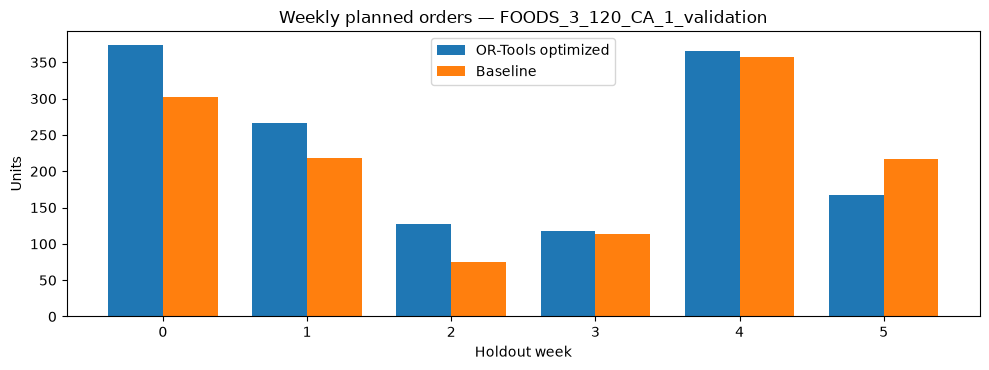

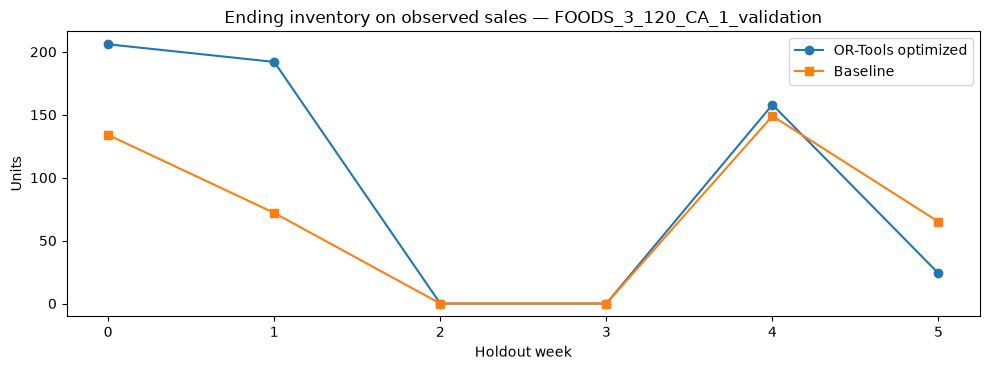

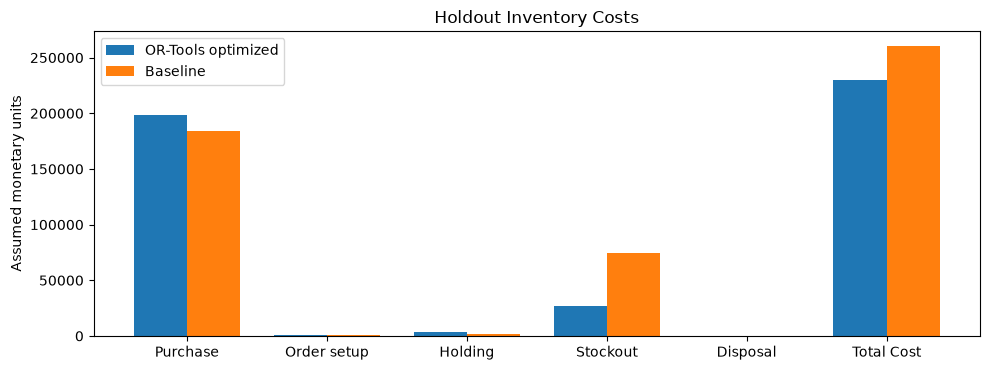

In [15]:
selected_sku = I[2]
per_sku_orders = ortools_plan.query('sku == @selected_sku').sort_values('week')
per_sku_inventory = ortools_inventory_trajectory.loc[ortools_inventory_trajectory['sku'] == selected_sku].sort_values('week')
baseline_sku_orders = baseline_plan.query('sku == @selected_sku').sort_values('week')
baseline_sku_inventory = baseline_inventory_trajectory.query('sku == @selected_sku').sort_values('week')
bar_width = 0.38
plt.figure(figsize=(10, 3.8))
plt.bar(per_sku_orders['week'].to_numpy() - bar_width/2,
        per_sku_orders['order_qty'], width=bar_width, label='OR-Tools optimized')
plt.bar(baseline_sku_orders['week'].to_numpy() + bar_width/2,
        baseline_sku_orders['order_qty'], width=bar_width, label='Baseline')
plt.title(f'Weekly planned orders — {selected_sku}')
plt.xlabel('Holdout week'); plt.ylabel('Units'); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 3.8))
plt.plot(per_sku_inventory['week'], per_sku_inventory['ending_inventory'], marker='o', label='OR-Tools optimized')
plt.plot(baseline_sku_inventory['week'], baseline_sku_inventory['ending_inventory'], marker='s', label='Baseline')
plt.title(f'Ending inventory on observed sales — {selected_sku}')
plt.xlabel('Holdout week'); plt.ylabel('Units'); plt.legend(); plt.tight_layout(); plt.show()


labels = ['Purchase', 'Order setup', 'Holding', 'Stockout', 'Disposal', 'Total Cost']

base_values = [baseline_holdout_metrics[k] for k in COST_COMPONENTS] + [baseline_holdout_metrics['cost']]
opt_values = [ortools_holdout_metrics[k] for k in COST_COMPONENTS] + [ortools_holdout_metrics['cost']]

xx = np.arange(len(labels))
plt.figure(figsize=(10, 3.8))
plt.bar(xx - 0.19, opt_values, width=0.38, label='OR-Tools optimized')
plt.bar(xx + 0.19, base_values, width=0.38, label='Baseline')
plt.xticks(xx, labels)
plt.ylabel('Assumed monetary units'); plt.title('Holdout Inventory Costs')
plt.legend(); plt.tight_layout(); plt.show()

## Save the evaluation 

In [16]:
(RESULTS_DIR/'holdout_metrics_ortools.json').write_text(
    json.dumps(ortools_holdout_metrics, indent=2) + '\n', encoding='utf-8'
)
ortools_scenario_details.to_csv(RESULTS_DIR/'holdout_scenario_ortools.csv', index=False)
ortools_inventory_trajectory.to_csv(RESULTS_DIR/'inventory_trajectory_ortools.csv', index=False)
order_schedule.to_csv(RESULTS_DIR/'order_schedule_ortools.csv')
print('Saved OR-Tools/CBC-only outputs in:', RESULTS_DIR)
print('  orders_ortools.csv')
print('  solver_ortools.json')
print('  holdout_metrics_ortools.json')
print('  inventory_trajectory_ortools.csv')
print('  order_schedule_ortools.csv')
# Save baseline-versus-optimized results for THIS solver only.
baseline_plan.to_csv(RESULTS_DIR/'baseline_orders.csv', index=False)
baseline_inventory_trajectory.to_csv(RESULTS_DIR/'baseline_inventory_trajectory.csv', index=False)
policy_comparison.to_csv(RESULTS_DIR/'holdout_comparison_ortools.csv', index=False)
(RESULTS_DIR/'baseline_holdout_metrics.json').write_text(
    json.dumps(baseline_holdout_metrics, indent=2) + '\n', encoding='utf-8'
)
print('Saved baseline and OR-Tools/CBC-only policy comparison outputs.')


Saved OR-Tools/CBC-only outputs in: /Users/zodii/Documents/Projects/Inventory_Optimization/results
  orders_ortools.csv
  solver_ortools.json
  holdout_metrics_ortools.json
  inventory_trajectory_ortools.csv
  order_schedule_ortools.csv
Saved baseline and OR-Tools/CBC-only policy comparison outputs.
